In [1]:
from typing import Tuple, List

import os
import rootutils

from tqdm import tqdm

rootutils.setup_root(os.path.abspath('./'), indicator=".project-root", pythonpath=True, dotenv=True, cwd=True)

# auto-loading of imports from outside scripts
%load_ext autoreload
%autoreload 2

In [2]:
from src.utils import create_df, compute_fingerprints, compute_descriptors, create_data, eval_metrics, plot_pred_true, plot_importance
from src.avail_descriptors import descriptors_all, descriptors_short

In [3]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from argparse import Namespace

from sklearn.model_selection import train_test_split

---
# Feature Extraction:

In [4]:
data_path = "data/Bradley_dataset_ok_3"
columns = ['line_number', 'smiles', 'cas', 'label', 'T']

df = create_df(data_path, columns)

In [5]:
data_args = {
    "descriptors": descriptors_all,

    "apply_norm": False,
    
    "create_fingerprints": False,
    "temp_column": True,
}

### Computing Features (load, if already precomputed)

In [47]:
from src.utils import create_or_load_data

In [48]:
dir_for_features = "saved_np_obj_with_embed_molecule"

X, labels, temp = X_bradley, labels_bradley, temp_bradley = create_or_load_data(df, data_args, f'{dir_for_features}/Bradley', load_data=True)

Loading data from saved_np_obj_with_embed_molecule/Bradley


In [49]:
not_all_nan = ~np.isnan(X).all(axis=1)

In [50]:
X = X[not_all_nan]
labels = labels[not_all_nan]
temp = temp[not_all_nan]


---
## Use Over-Sampling for minority class

In [51]:
from src.utils import perform_smote

In [52]:
X, labels, temp = perform_smote(X, labels, temp, k_neighbors=5)

---

### If you want to simulate NaNs in the temperature:

In [53]:
nan_proba = 0.0

np.random.seed(42)
mask = np.random.choice([True, False], size=temp.shape, p=[nan_proba, 1 - nan_proba])
temp_with_nans = temp.copy()
temp_with_nans[mask] = np.nan

In [54]:
temp = temp_with_nans

---
# MultiTask Learning with Lightning:

In [55]:
from src.multitask_nn import MultiTaskModel, create_datasets

from lightning.pytorch.callbacks import Callback, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning import seed_everything, Trainer
from torch.utils.data import DataLoader

from datetime import datetime

In [56]:
seed_everything(42, verbose=False)

42

In [99]:
cfg = Namespace(
    project_name="bradley",
    
    normalize_data=True,
    train_size=0.8,

    batch_size=512,
    lr=3e-4,
    scheduler_gamma=0.99,
    max_epochs=30,

    hid_dim=1024,
    depth=6,
    use_residual=True,
    drop=0.2,

    cl_loss_coef=1.,
    pos_label_weight=1,
    reg_loss_coef=1e-4,

    use_learnable_loss_weights=False,

    num_workers=0,
    persistent_workers=False,
)

In [100]:
train_data, val_data = create_datasets(X, labels, temp, use_norm=cfg.normalize_data, train_size=cfg.train_size)

# persistent_workers=True reduces overhead of creating workers
train_loader = DataLoader(train_data, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)
val_loader = DataLoader(val_data, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, persistent_workers=cfg.persistent_workers)

In [101]:
input_dim = X.shape[1]
model = MultiTaskModel(
    input_dim=input_dim,

    hidden_dim=cfg.hid_dim,
    depth=cfg.depth,
    use_residual=cfg.use_residual,
    drop=cfg.drop,

    lr=cfg.lr,
    scheduler_gamma=cfg.scheduler_gamma,

    cl_loss_coef=cfg.cl_loss_coef,
    pos_label_weight=cfg.pos_label_weight,
    reg_loss_coef=cfg.reg_loss_coef,

    use_learnable_loss_weights=cfg.use_learnable_loss_weights,
)

current_date = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

logger = TensorBoardLogger(
    save_dir="tb_logs/", name=cfg.project_name
)

checkpoint_callback = ModelCheckpoint(
    dirpath=f"checkpoints/{cfg.project_name}-{current_date}",
    filename="{epoch:02d}-{val_loss:.4f}",
    save_top_k=1,
    monitor="V_tot",
    mode="min",
    save_last=True,
)

trainer = Trainer(
    logger=logger,
    callbacks=[checkpoint_callback],
    max_epochs=cfg.max_epochs,
    gradient_clip_val=1.0,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [102]:
trainer.fit(model, train_loader, val_loader)


  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | shared       | Sequential        | 5.4 M  | train
1 | classifier   | Sequential        | 1.1 M  | train
2 | regressor    | Sequential        | 1.1 M  | train
3 | val_accuracy | BinaryAccuracy    | 0      | train
4 | val_f1       | BinaryF1Score     | 0      | train
5 | val_roc_auc  | BinaryAUROC       | 0      | train
6 | val_r2_class | R2Score           | 0      | train
7 | val_mse      | MeanSquaredError  | 0      | train
8 | val_mae      | MeanAbsoluteError | 0      | train
9 | val_r2_reg   | R2Score           | 0      | train
-----------------------------------------------------------
7.5 M     Trainable params
0         Non-trainable params
7.5 M     Total params
29.843    Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/aleksandr.varlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.
/home/aleksandr.varlamov/phase-prediction/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


### Doing T(distance) plot:

In [103]:
from src.plot_utils import plot_T_from_distance_for_nn

Computing T(distance) plot: 100%|██████████| 1/1 [00:00<00:00, 86.89it/s]


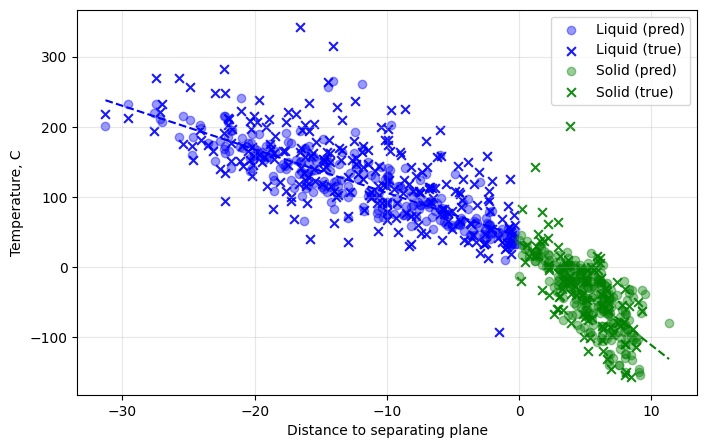

In [104]:
plot_T_from_distance_for_nn(model, val_loader, max_batches=1)

---
# Comparing to catboost:

In [105]:
raise Exception("stop")

Exception: stop

In [36]:
from catboost import CatBoostClassifier, CatBoostRegressor
from src.utils import eval_metrics

In [37]:
X_train, X_val, y_train, y_val, temp_train, temp_val = train_test_split(X, labels, temp, train_size=cfg.train_size)

In [ ]:
y_train

array([0, 0, 1, ..., 1, 1, 0])

In [39]:
y_train = y_train[~np.isnan(temp_train)]
y_val = y_val[~np.isnan(temp_val)]

X_train = X_train[~np.isnan(temp_train)]
X_val = X_val[~np.isnan(temp_val)]

temp_train = temp_train[~np.isnan(temp_train)]
temp_val = temp_val[~np.isnan(temp_val)]


In [40]:
catboost_reg = CatBoostRegressor(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_reg.fit(X_train, temp_train)
temp_pred = catboost_reg.predict(X_val)

Learning rate set to 0.066039
0:	learn: 94.3519382	total: 70.2ms	remaining: 1m 10s
100:	learn: 46.4314920	total: 593ms	remaining: 5.28s
200:	learn: 43.3662481	total: 1.01s	remaining: 4s
300:	learn: 41.3171338	total: 1.35s	remaining: 3.14s
400:	learn: 39.8060010	total: 1.69s	remaining: 2.53s
500:	learn: 38.6730864	total: 2.02s	remaining: 2.02s
600:	learn: 37.5600825	total: 2.38s	remaining: 1.58s
700:	learn: 36.6667600	total: 2.75s	remaining: 1.17s
800:	learn: 35.8376159	total: 3.11s	remaining: 772ms
900:	learn: 35.1629278	total: 3.47s	remaining: 381ms
999:	learn: 34.4720901	total: 3.83s	remaining: 0us


In [ ]:
eval_metrics(temp_val, temp_pred, type="regression")

{'MSE': 1529.6653201207102,
 'MAE': 28.822144603354367,
 'R2': 0.8375289880153641}

In [42]:
catboost_cl = CatBoostClassifier(
    # iterations=1000,
    # depth=10,
    # learning_rate=0.01,
    verbose=100,
)

catboost_cl.fit(X_train, y_train)
y_pred = catboost_cl.predict(X_val)

Learning rate set to 0.0375
0:	learn: 0.6384212	total: 6.34ms	remaining: 6.33s
100:	learn: 0.1934114	total: 580ms	remaining: 5.16s
200:	learn: 0.1724797	total: 1.19s	remaining: 4.74s
300:	learn: 0.1582888	total: 1.76s	remaining: 4.08s
400:	learn: 0.1466623	total: 2.53s	remaining: 3.77s
500:	learn: 0.1380498	total: 3.1s	remaining: 3.08s
600:	learn: 0.1308123	total: 3.65s	remaining: 2.42s
700:	learn: 0.1247709	total: 4.21s	remaining: 1.8s
800:	learn: 0.1184700	total: 4.76s	remaining: 1.18s
900:	learn: 0.1124745	total: 5.32s	remaining: 585ms
999:	learn: 0.1075689	total: 5.94s	remaining: 0us


In [ ]:
eval_metrics(y_val, y_pred, type="classification")

{'ACC': 0.9464563862928349,
 'F1': 0.8780487804878049,
 'BAL-ACC': 0.9140121705650508,
 'ROC-AUC': 0.9140121705650508,
 'R2': 0.6933913727574197}